In [12]:
import pandas as pd
import ast
import os

In [13]:
os.environ['R_HOME'] = '/home/ZHX/anaconda3/envs/GraphST/lib/R'
current_path = os.getcwd()
print("当前路径：", current_path)
file_path=current_path

当前路径： /home/ZHX/code111/GraphST-main/stMVCL/Tutorial


In [14]:
# 读取Excel文件
df = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_result.xlsx', engine='openpyxl',sheet_name='ARI',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件
df2 = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_result.xlsx', engine='openpyxl',sheet_name='NMI',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件

# 显示DataFrame的内容
print(df)
print(df2)
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"

          SCANPY   STAGATE      SEDR    MuCoST   SpaNCMG   GraphST    stMVCL
slice                                                                       
151507  0.334461  0.530045  0.492608  0.474496  0.485173  0.435432  0.510214
151508  0.316041  0.513626  0.501629  0.489397  0.457870  0.487444  0.472501
151509  0.252854  0.486830  0.508992  0.488338  0.472901  0.497755  0.498782
151510  0.365941  0.474296  0.447986  0.509342  0.474703  0.488737  0.507419
151669  0.197470  0.528670  0.398849  0.488605  0.522517  0.464120  0.503057
151670  0.203648  0.386427  0.313678  0.371796  0.514166  0.520621  0.489563
151671  0.279378  0.585821  0.618768  0.610406  0.572237  0.598961  0.600932
151672  0.327288  0.562504  0.729961  0.622079  0.579564  0.619960  0.579339
151673  0.329325  0.561786  0.579467  0.569730  0.586847  0.628183  0.630997
151674  0.362641  0.432621  0.535272  0.613123  0.452566  0.621041  0.623057
151675  0.300671  0.437512  0.508921  0.537463  0.580486  0.556052  0.625730

In [15]:
df.mean()


SCANPY     0.291701
STAGATE    0.489974
SEDR       0.515952
MuCoST     0.526565
SpaNCMG    0.520112
GraphST    0.544556
stMVCL     0.551935
dtype: float64

In [16]:
df2.mean()

SCANPY     0.398080
STAGATE    0.625600
SEDR       0.651142
MuCoST     0.663833
SpaNCMG    0.640688
GraphST    0.673504
stMVCL     0.679870
dtype: float64

In [17]:
df.median()

SCANPY     0.308356
STAGATE    0.500228
SEDR       0.508957
MuCoST     0.523403
SpaNCMG    0.518342
GraphST    0.538336
stMVCL     0.544777
dtype: float64

In [18]:
df2.median()

SCANPY     0.403700
STAGATE    0.645146
SEDR       0.662695
MuCoST     0.666935
SpaNCMG    0.634835
GraphST    0.669361
stMVCL     0.680353
dtype: float64

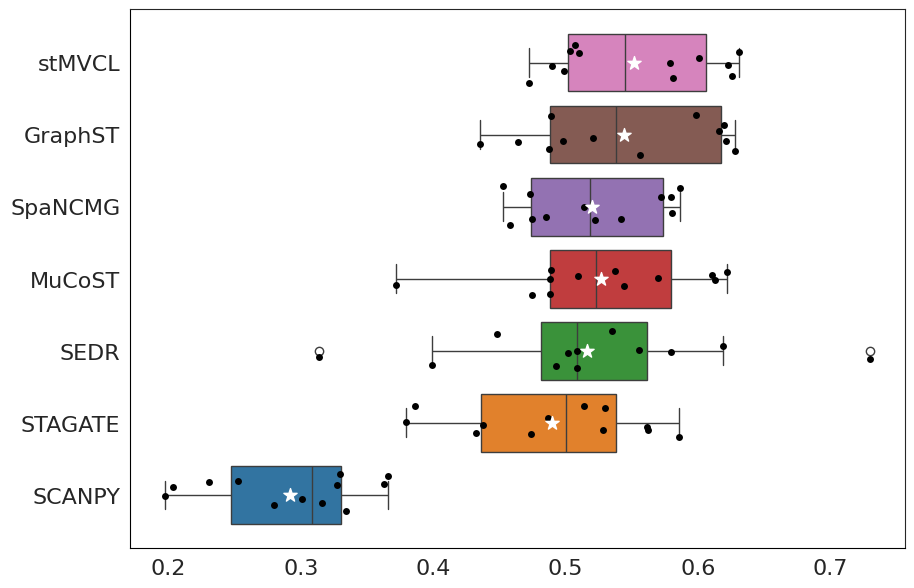

In [19]:
#绘制12张切片ARI的水平箱线图和散点图
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 7))

ax = sns.boxplot(data=df, orient='h')
ax = sns.stripplot(data=df,orient='h',color='black' ,jitter=0.3, size=5)
mean = df.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
ax.invert_yaxis()
# ax.set_title("DLPFC")

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 移除网格线（内框线）
ax.grid(False)

plt.savefig(os.path.join(result_path,"DLPFC_ARI_h_box_strip.png"))

plt.show()


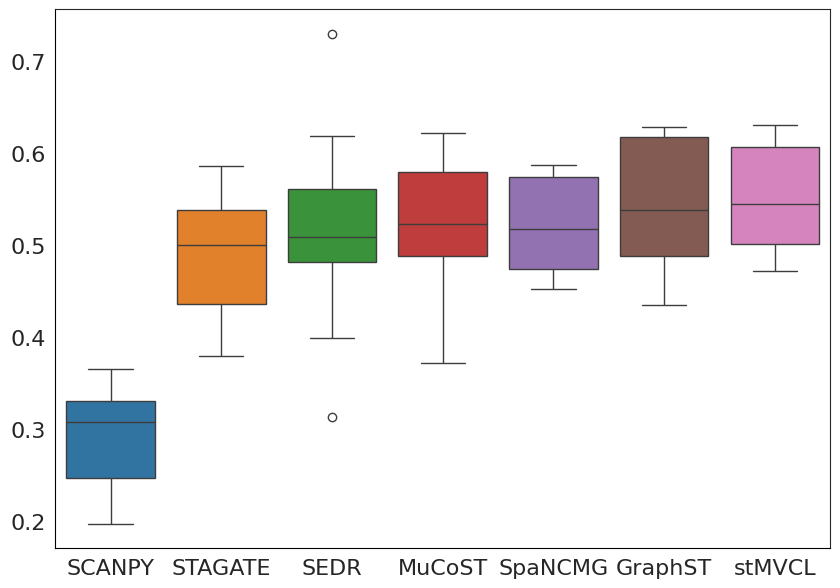

In [5]:
#绘制12张切片ARI的垂直箱线图和散点图
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
# 创建图像（设置图像大小）
plt.figure(figsize=(10, 7))  # 宽 10 英寸，高 8 英寸

# 绘制垂直箱线图
ax = sns.boxplot(data=df, orient='v')

# 计算均值
mean = df.mean()
# 清空 y 轴标签（不是必须）
ax.set_xlabel('', labelpad=50)
# ax.set_title("ARI")

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ARI_v_box_strip.png"), bbox_inches='tight')

# 显示图形
plt.show()

In [6]:
df.mean()

SCANPY     0.291701
STAGATE    0.489974
SEDR       0.515952
MuCoST     0.526565
SpaNCMG    0.520112
GraphST    0.544556
stMVCL     0.551935
dtype: float64

/tmp/ipykernel_1128988/2517921632.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')


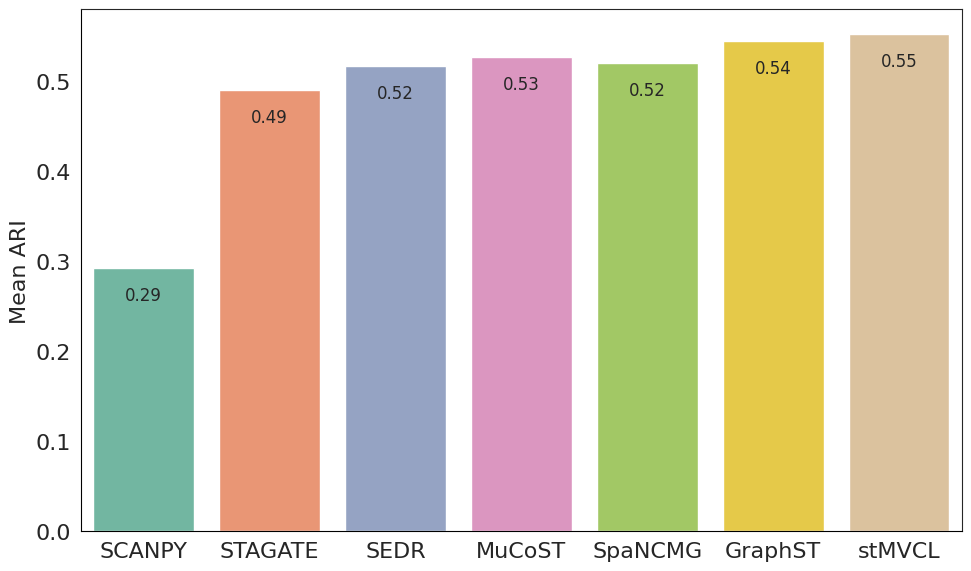

In [7]:
#绘制12张切片ARI均值的柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 计算每列的均值
mean_values = df.mean()

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(mean_values.values):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_MeanARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


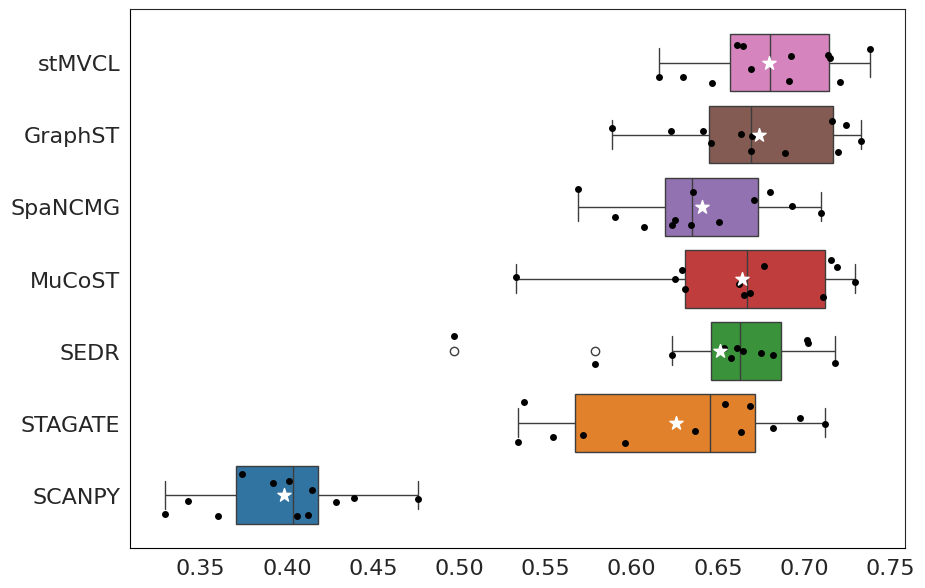

In [8]:
#绘制12张切片NMI的水平箱线图和散点图
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 7))

ax = sns.boxplot(data=df2, orient='h')
ax = sns.stripplot(data=df2,orient='h',color='black' ,jitter=0.3, size=5)
mean = df2.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
ax.invert_yaxis()
# ax.set_title("DLPFC")
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')


plt.savefig(os.path.join(result_path,"DLPFC_NMI_h_box_strip.png"))

plt.show()


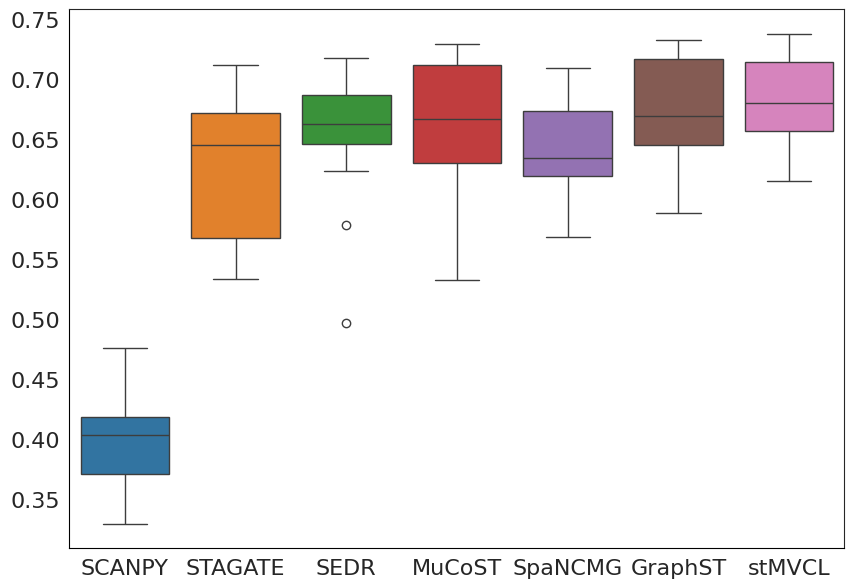

In [9]:
#绘制12张切片NMI的垂直箱线图和散点图
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import os

# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
# 创建图像（设置图像大小）
plt.figure(figsize=(10,7))  # 宽 10 英寸，高 8 英寸

# 绘制垂直箱线图
ax = sns.boxplot(data=df2, orient='v')

# 计算均值
mean = df2.mean()
# 清空 y 轴标签（不是必须）
ax.set_xlabel('', labelpad=50)
# ax.set_title("ARI")
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_NMI_v_box_strip.png"), bbox_inches='tight')

# 显示图形
plt.show()

In [10]:

df2.median()

SCANPY     0.403700
STAGATE    0.645146
SEDR       0.662695
MuCoST     0.666935
SpaNCMG    0.634835
GraphST    0.669361
stMVCL     0.680353
dtype: float64

/tmp/ipykernel_1128988/202608038.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')


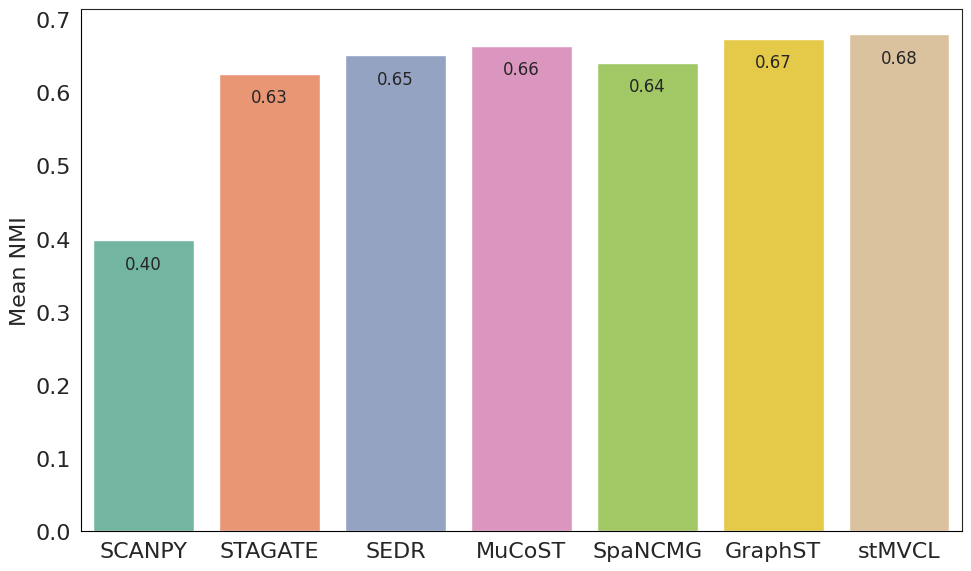

In [11]:
#绘制12张切片NMI均值的柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 计算每列的均值
mean_values = df2.mean()

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=mean_values.index, y=mean_values.values, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean NMI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(mean_values.values):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_MeanNMI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


2、10X Visium 冠状小鼠切片cornal mouse brain数据集

/tmp/ipykernel_2399611/3259671509.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


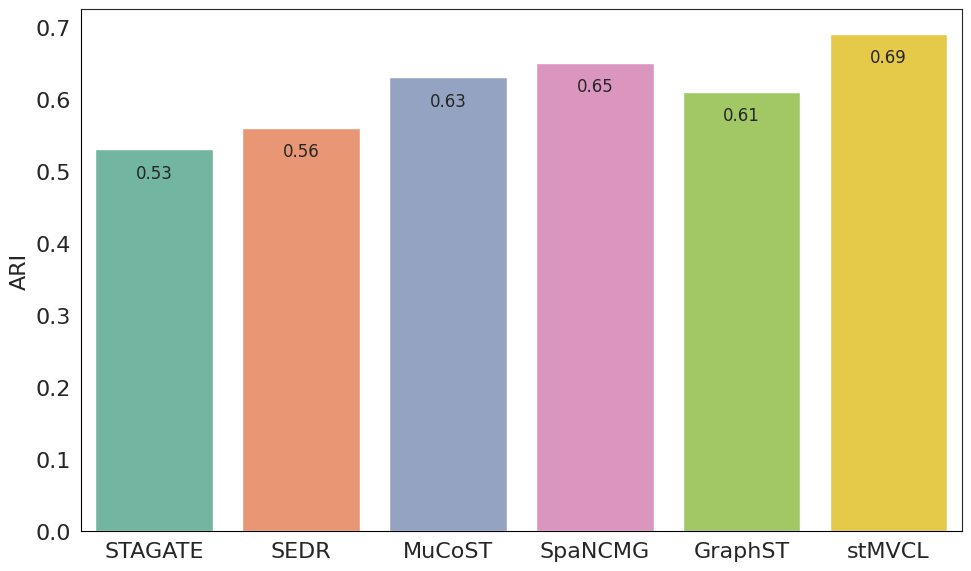

In [1]:
#绘制10X Visium 冠状小鼠切片cornal mouse brain数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stMVCL']
ari_scores = [ 0.53, 0.56, 0.63, 0.65, 0.61, 0.69]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=6)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "cornal mouse brain_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


3、10X Visium Mouse_anterior_brain 小鼠前脑数据集

/tmp/ipykernel_2615164/3541026988.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


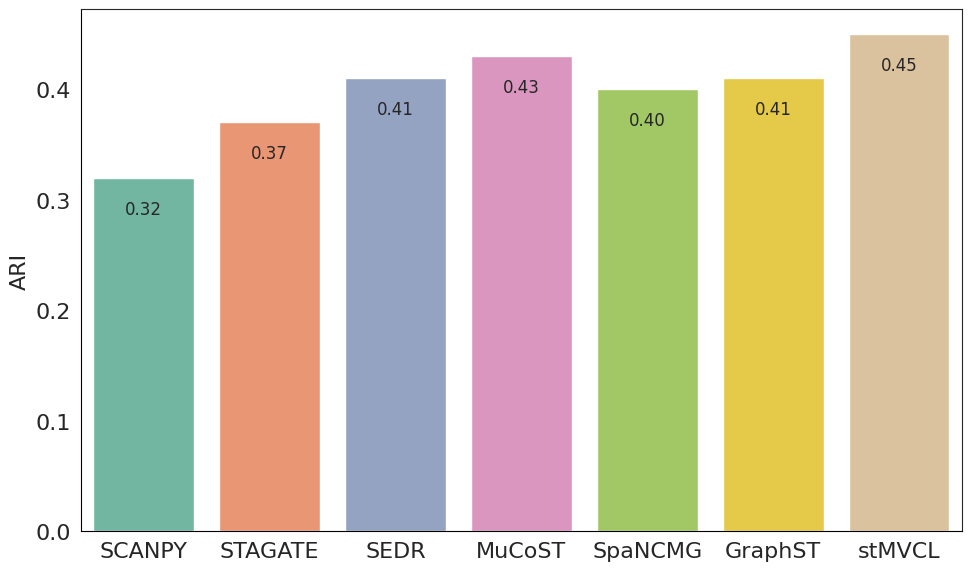

In [2]:
#绘制10X Visium Mouse_anterior_brain 小鼠前脑数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['SCANPY', 'STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stMVCL']
ari_scores = [0.32, 0.37, 0.41, 0.43, 0.40, 0.41, 0.45]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "MA_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


4、osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集

/tmp/ipykernel_2615164/3880340564.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


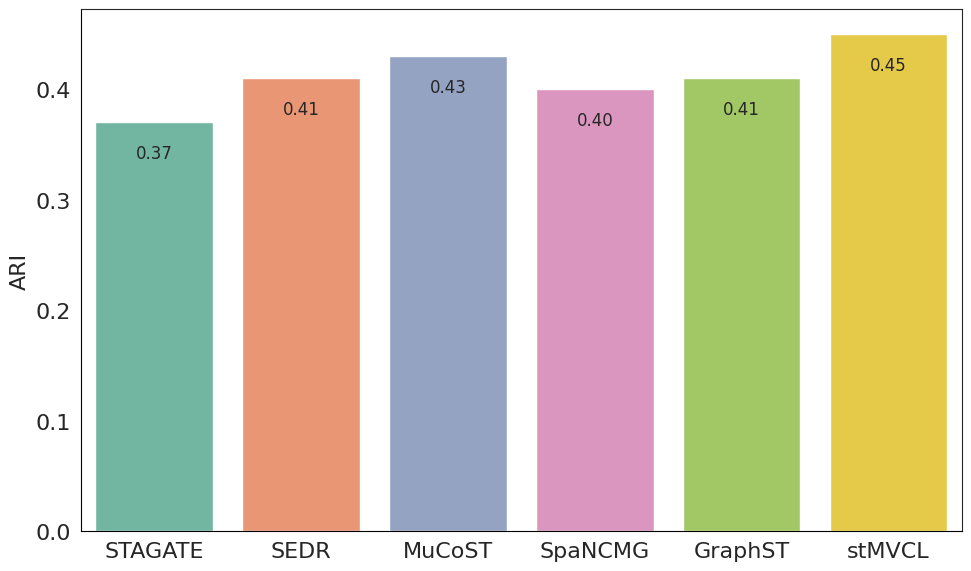

In [3]:
#绘制10X Visium Mouse_anterior_brain 小鼠前脑数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stMVCL']
ari_scores = [ 0.37, 0.41, 0.43, 0.40, 0.41, 0.45]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "MA_ARI_bar2.png"), bbox_inches='tight')

# 显示图形
plt.show()


/tmp/ipykernel_386246/2012515237.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


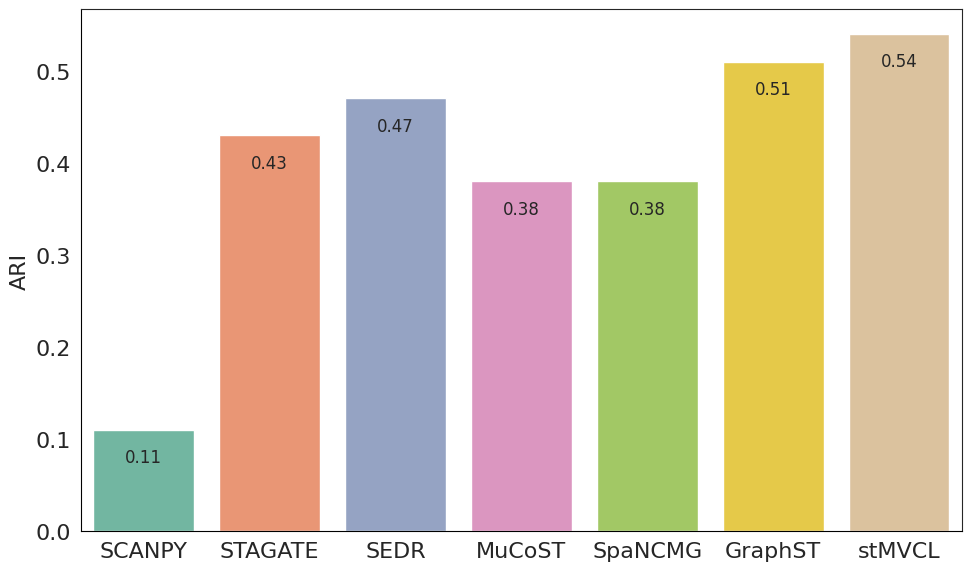

In [2]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['SCANPY', 'STAGATE', 'SEDR', 'MuCoST', 'SpaNCMG', 'GraphST', 'stMVCL']
ari_scores = [0.11, 0.43, 0.47, 0.38, 0.38, 0.51, 0.54]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 6))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "osmFISH_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


消融实验

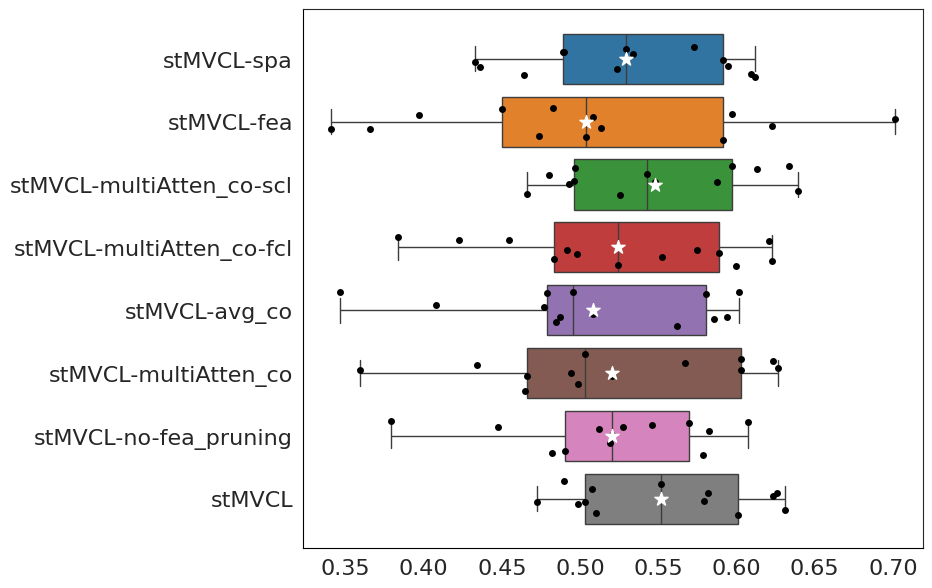

In [11]:
#消融实验ARI的水平箱线图和散点图
import os
import pandas as pd
import matplotlib.pyplot as plt
import xlrd
import seaborn as sns
import matplotlib as mpl
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(8, 7))

result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
df = pd.read_excel('/home/ZHX/code111/GraphST-main/final_result/DLPFC_ablation.xlsx', engine='openpyxl',index_col=0)  # 指定引擎为openpyxl以处理.xlsx文件


ax = sns.boxplot(data=df, orient='h')
ax = sns.stripplot(data=df,orient='h',color='black' ,jitter=0.3, size=5)
mean = df.mean()
ax.set_ylabel('',rotation=0, labelpad=50, va='center')
for i, val in enumerate(mean):
    ax.scatter(val, i, color='white', s=100, marker='*',zorder=10, label=f'Mean {df.columns[i]}')
# 倒序 y 轴
# ax.invert_yaxis()
# ax.set_title("DLPFC")

# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 移除网格线（内框线）
ax.grid(False)

plt.savefig(os.path.join(result_path,"DLPFC_ablation_ARI_h_box_strip.png"))

plt.show()


/tmp/ipykernel_1289360/4166243774.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


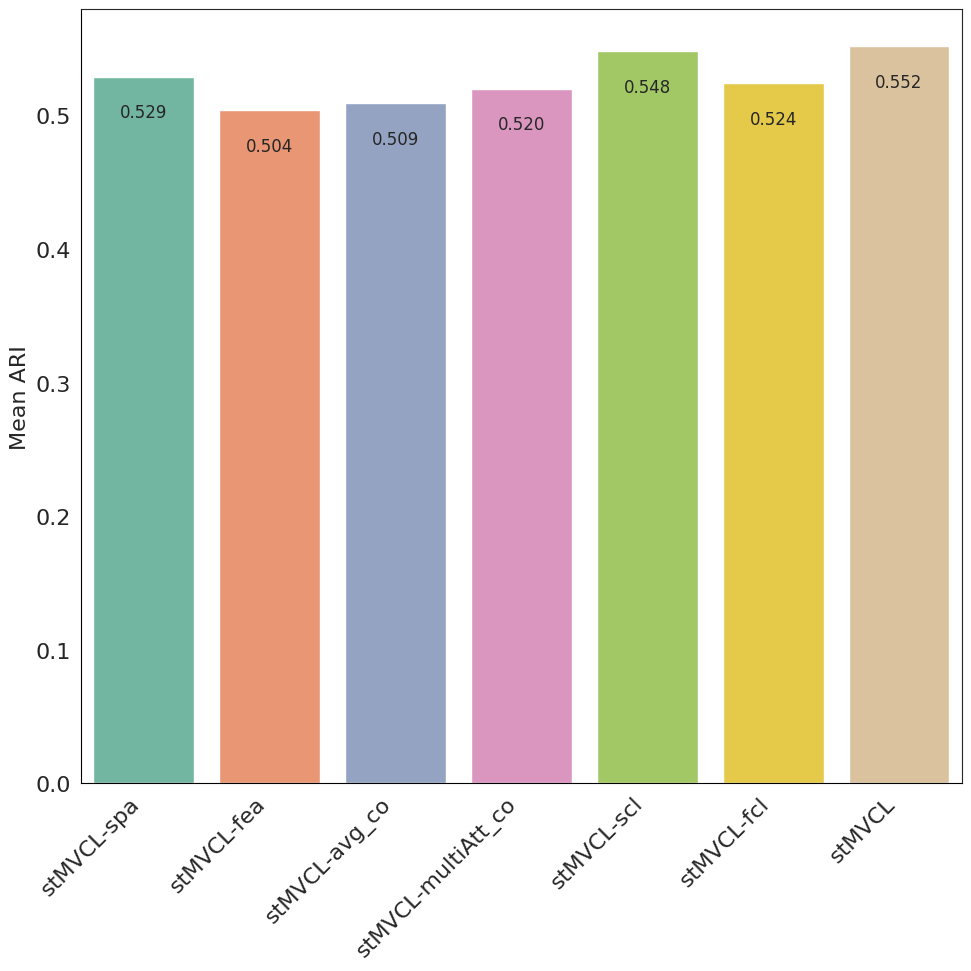

In [35]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['stMVCL-spa', 'stMVCL-fea', 'stMVCL-avg_co', 'stMVCL-multiAtt_co', 'stMVCL-scl', 'stMVCL-fcl', 'stMVCL']
ari_scores = [0.529, 0.504, 0.509, 0.520, 0.548, 0.524, 0.552]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(10, 10))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.3f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ablation_ARI_bar.png"), bbox_inches='tight')

# 显示图形
plt.show()


/tmp/ipykernel_1289360/1844277177.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=ari_scores, palette='Set2')


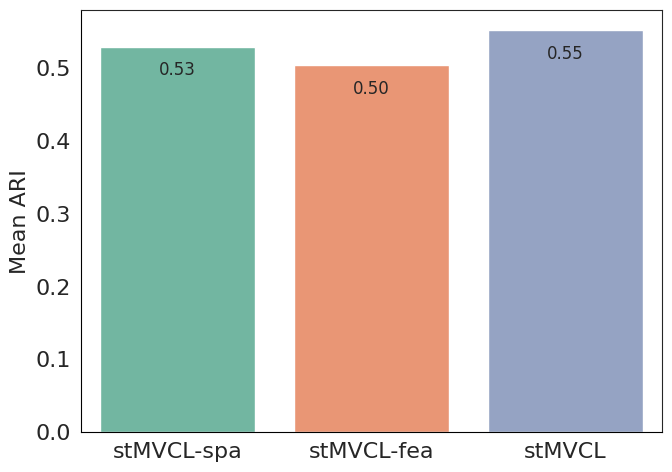

In [32]:
#绘制1osmFISH SScortex mouse 小鼠体感皮层（osmFISH）数据集ARI柱状图
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib as mpl
result_path = "/home/ZHX/code111/GraphST-main/final_result/result_visualization/"
# 模型名称和对应的ARI分数（请替换为实际值）
models = ['stMVCL-spa', 'stMVCL-fea',  'stMVCL']
ari_scores = [0.529, 0.504,  0.552]  # 请替换为实际的ARI分数

# 创建图像并设置大小
# 设置颜色和字体
sns.set_style("white")  # 设置背景为白色
colors = sns.color_palette(n_colors=7)
mpl.rcParams.update({'font.size': 16})
plt.figure(figsize=(7, 5))

# 绘制柱状图
ax = sns.barplot(x=models, y=ari_scores, palette='Set2')

# 添加标题和标签
# plt.title("Mean ARI Values for Each Method", fontsize=18)
plt.xlabel("")
plt.ylabel("Mean ARI")

# 旋转 x 轴标签
# plt.xticks(rotation=45, ha='right')
ax.set_xlabel('', labelpad=50)
# 添加每个柱子的数值标签
for i, value in enumerate(ari_scores):
    ax.text(i, value - 0.02, f"{value:.2f}", ha='center', va='top', fontsize=12)

# 自动调整布局防止遮挡
plt.tight_layout()
# 设置边框样式
ax.spines['top'].set_visible(True)    # 移除上边框
ax.spines['right'].set_visible(True)  # 移除右边框
ax.spines['bottom'].set_visible(True)  # 保留下边框
ax.spines['left'].set_visible(True)    # 保留左边框

# 设置边框颜色为黑色
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# 保存图像
plt.savefig(os.path.join(result_path, "DLPFC_ablation_ARI_bar2.png"), bbox_inches='tight')

# 显示图形
plt.show()
